In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
sys.path.append('../src')

from cnn import *
from datas import *
from train import *

In [3]:
from torch.utils.data import DataLoader
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
%matplotlib inline

In [4]:
timepoint = '2H'

bigwig_path = '../data/bws_for_predictor/SPT16_4D_2HdTAG_Sox2_S46_1_120_sorted.bw'
pol2_bigwig_path= '../data/Pol2/SPT16_2HdTAG_Pol2.bw'
fasta_path = '../data/GRCm38.primary_assembly.genome.fa'
bed_path = '../data/bed_files/GFP_TTseq_max_sorted_top_quintile.bed'

signal_bins = None
batch_size = 256
epochs = 1000
lr = 1e-3
weight_decay=1e-9
device = 'mps'
weight_decay = 0
patience = 10
sidelines = 0
target_smoothing = False

In [5]:
model_dir = 'models_gb'

window_left = -510
window_right = 510*3

In [6]:
dataset = SequenceDualBigWigDataset(
    fasta_path=str(fasta_path),
    k4_bigwig_path=str(pol2_bigwig_path),
    target_bigwig_path=str(bigwig_path),
    bed_path=str(bed_path),
    signal_bins=signal_bins,
    window_left=window_left,
    window_right=window_right
)

In [7]:
get_dataset_composition(dataset, only_peaks=True)

------------------------------
Nucleotide Frequencies (Analyzed 3653 sequences):
  A: 26.09%
  C: 23.09%
  G: 23.96%
  T: 26.85%
------------------------------
  GC Content: 47.06%
------------------------------


In [8]:
len(dataset)

3653

### Sanity check

In [7]:
import numpy as np

idx = round(np.random.rand() * len(dataset))
*x, y = dataset[idx]
x[0].shape, x[1].shape, y.shape

(torch.Size([4, 1020]), torch.Size([1020]), torch.Size([1020]))

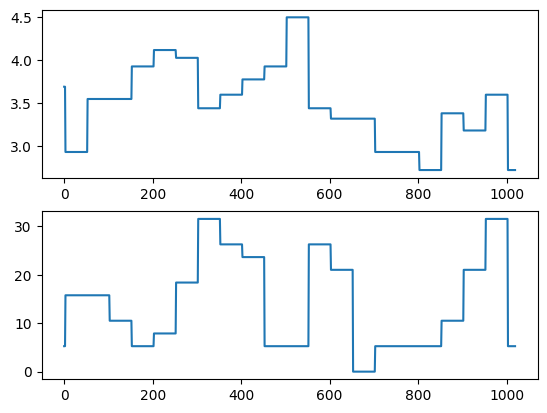

In [8]:
fig, axs = plt.subplots(2, 1)
axs[0].plot(x[1])
axs[1].plot(y)

### Train

/var/folders/1g/26g72_qd5qn5k3q89zh7_6240000gn/T/ipykernel_74957/1186029749.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


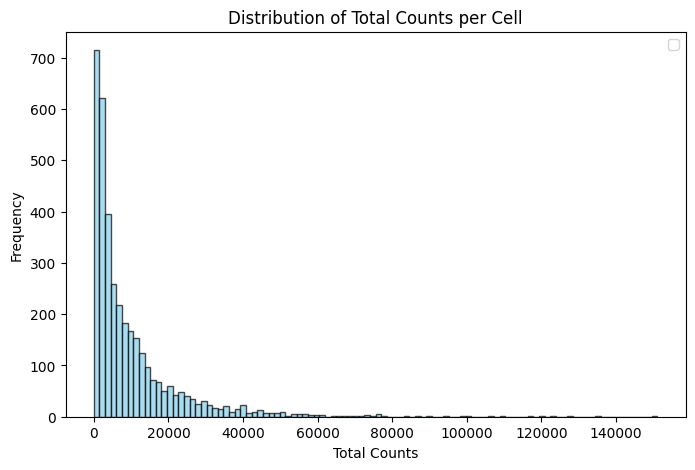

In [9]:
loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)

tot_counts = []
for _, _, y_batch in loader:
    tot_counts.extend(y_batch.sum(axis=-1).numpy())

plt.figure(figsize=(8, 5))
plt.hist(tot_counts, bins=100, color='skyblue', edgecolor='black', alpha=0.7)

plt.title("Distribution of Total Counts per Cell")
plt.xlabel("Total Counts")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [10]:
config = TrainConfig(
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    patience=patience,
    device=device,
    loss_type='bpnet',
    target_smoothing=target_smoothing
)

model = train_cnn_regressor(
    dataset=dataset,
    batch_size=batch_size,
    config=config,
)

Receptive field: 535 bp (Sequence length: 1020 bp)


Epoch 1/1000 - train: 1594335 | val: 91654 (counts: 6641, profile: 85012)
Epoch 2/1000 - train: 111359 | val: 83884 (counts: 9175, profile: 74709)
Epoch 3/1000 - train: 85597 | val: 73773 (counts: 2562, profile: 71211)
Epoch 4/1000 - train: 77936 | val: 70547 (counts: 1315, profile: 69232)
Epoch 5/1000 - train: 75933 | val: 69131 (counts: 835, profile: 68296)
Epoch 6/1000 - train: 73747 | val: 68291 (counts: 687, profile: 67604)
Epoch 7/1000 - train: 73148 | val: 67641 (counts: 522, profile: 67119)
Epoch 8/1000 - train: 72590 | val: 67167 (counts: 427, profile: 66739)
Epoch 9/1000 - train: 72532 | val: 66845 (counts: 367, profile: 66478)
Epoch 10/1000 - train: 71655 | val: 66509 (counts: 298, profile: 66211)
Epoch 11/1000 - train: 71683 | val: 66239 (counts: 257, profile: 65982)
Epoch 12/1000 - train: 70722 | val: 66036 (counts: 228, profile: 65808)
Epoch 13/1000 - train: 71186 | val: 65848 (counts: 215, profile: 65633)
Epoch 14/1000 - train: 71894 | val: 65684 (counts: 206, profile: 6

In [14]:
import time
from pathlib import Path

date = time.strftime("%Y%m%d")
model_name = f'seqpol2_{timepoint}_{date}'
output_model_path = Path(f'../{model_dir}/{model_name}.pt')

model.save_model(output_model_path)

In [15]:
import os 
import torch
os.makedirs(f'../{model_dir}/loaders', exist_ok=True)

torch.save(model.val_loader, f'../{model_dir}/loaders/{model_name}_val.pt')
torch.save(model.test_loader, f'../{model_dir}/loaders/{model_name}_test.pt')
torch.save(model.train_loader, f'../{model_dir}/loaders/{model_name}_train.pt')

### Analysis

In [ ]:
import torch 
import os 

model_dir = 'models_gb'
model_name = 'seqpol2_2H_20260506'
model = BPNetK4Model.load_model(f'../{model_dir}/{model_name}.pt')
model.test_loader = torch.load(f'../{model_dir}/loaders/{model_name}_test.pt', weights_only=False)
model.train_loader = torch.load(f'../{model_dir}/loaders/{model_name}_train.pt', weights_only=False)
model.val_loader = torch.load(f'../{model_dir}/loaders/{model_name}_val.pt', weights_only=False)

results_dir = f'../results/{model_name}'
if '_gb' in model_dir:
    results_dir+='_gb'
os.makedirs(results_dir, exist_ok=True)

In [10]:
import torch

loaders = {
    'Train': model.train_loader,
    'Validation': model.val_loader,
    'Test': model.test_loader
}

# Get a reference batch for shapes/values
sample_batch = next(iter(model.test_loader))
*x_ref, y_ref = sample_batch

# 1. Permuted Baseline (shuffled inputs)
perm_idx = torch.randperm(x_ref[0].size(0))
perm_x = [x[perm_idx] for x in x_ref]
perm_loader = DataLoader(torch.utils.data.TensorDataset(*perm_x, y_ref), batch_size=32)

# 2. Gaussian Baseline
gauss_x = [torch.randn_like(x) for x in x_ref]
gauss_loader = DataLoader(torch.utils.data.TensorDataset(*gauss_x, y_ref), batch_size=32)

# 3. Uniform Baseline (values between 0 and 1)
unif_x = [torch.rand_like(x) for x in x_ref]
unif_loader = DataLoader(
    torch.utils.data.TensorDataset(*unif_x, y_ref), 
    batch_size=32
)

loaders['Uniform'] = unif_loader
loaders['Permuted'] = perm_loader
loaders['Gaussian'] = gauss_loader

Evaluating Train split...
Evaluating Validation split...
Evaluating Test split...
Evaluating Uniform split...
Evaluating Permuted split...
Evaluating Gaussian split...


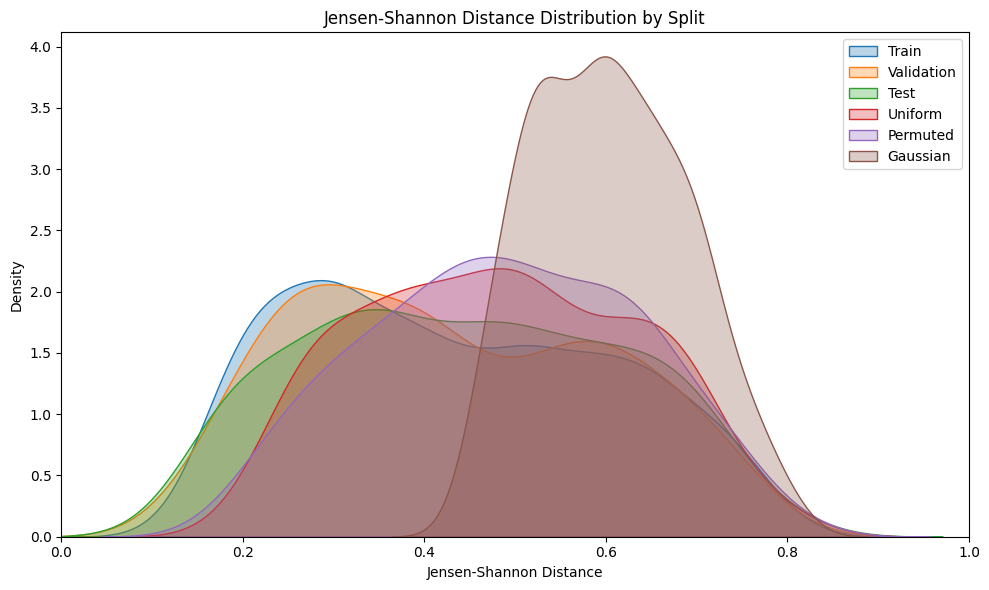

,Split,Pearson,Spearman
0,Train,0.874397,0.901942
1,Validation,0.877937,0.893590
2,Test,0.873445,0.887967
3,Uniform,0.107463,0.147532
4,Permuted,0.091423,0.071687
5,Gaussian,0.019180,0.052746


In [15]:
from train import evaluate_model_metrics
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

correlations = []
plt.figure(figsize=(10, 6))

loader_metrics = {}

for split_name, loader in loaders.items():
    if loader is None:
        continue
        
    print(f"Evaluating {split_name} split...")
    metrics = evaluate_model_metrics(
        model, loader, 
        device="mps", 
        min_profile=model.min_profile
    )

    loader_metrics[split_name] = metrics
    
    pcorr, _ = pearsonr(metrics['log_counts_true'], metrics['log_counts_pred'])
    scorr, _ = spearmanr(metrics['log_counts_true'], metrics['log_counts_pred'])

    correlations.append({
        'Split': split_name,
        'Pearson': pcorr,
        'Spearman': scorr
    })
    
    sns.kdeplot(data=metrics['profile_jsd'], label=split_name, fill=True, alpha=0.3)

plt.title('Jensen-Shannon Distance Distribution by Split')
plt.xlabel('Jensen-Shannon Distance')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(f'{results_dir}/jsd.png')
plt.show()

df_corr = pd.DataFrame(correlations)
display(df_corr)



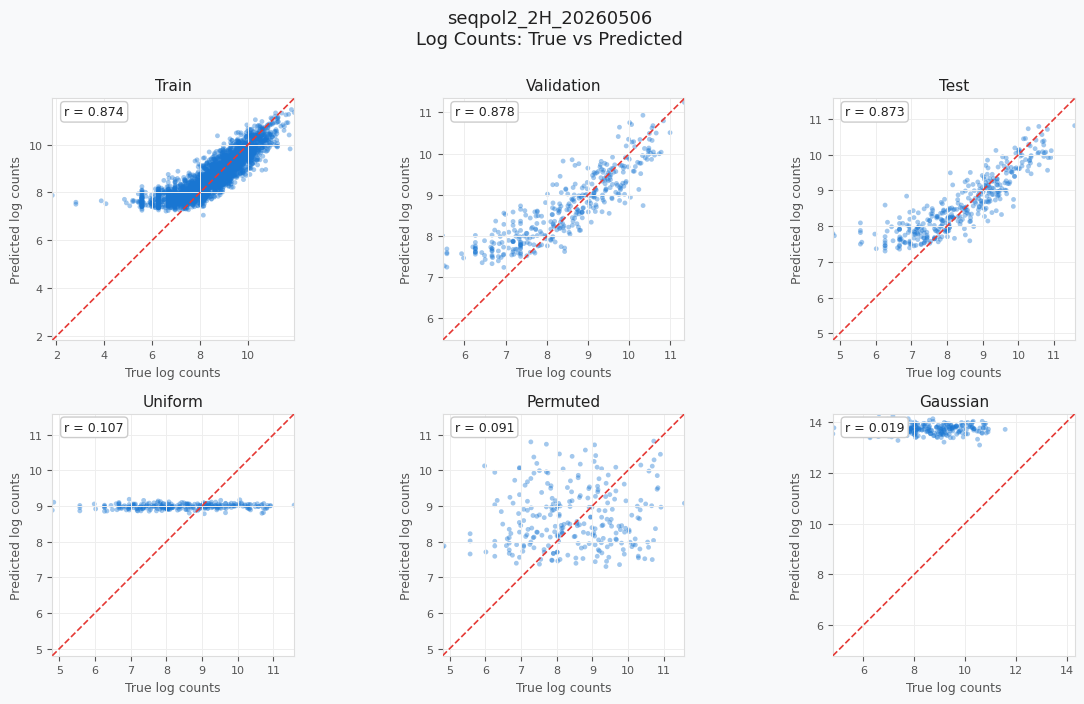

In [16]:
fig, axs = plt.subplots(2, 3, figsize=(12, 7))
fig.patch.set_facecolor('#f8f9fa')
axs = axs.flatten()

for i, (split_name, metrics) in enumerate(loader_metrics.items()):
    ax = axs[i]
    x = np.array(metrics['log_counts_true'])
    y = np.array(metrics['log_counts_pred'])

    ax.scatter(x, y, alpha=0.4, s=12, color='#1976d2', edgecolors='none', rasterized=True)

    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, color='#e53935', lw=1.2, ls='--', zorder=3, label='y = x')

    r, _ = pearsonr(x, y)
    ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=9, color='#212121',
            bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=0.3'))

    ax.set_facecolor('#ffffff')
    ax.set_title(split_name, fontsize=11, color='#212121', pad=6)
    ax.set_xlabel('True log counts', fontsize=9, color='#555555')
    ax.set_ylabel('Predicted log counts', fontsize=9, color='#555555')
    ax.tick_params(colors='#555555', labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#dddddd')
    ax.grid(True, color='#eeeeee', lw=0.7, zorder=0)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')

for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle(f'{model_name}\nLog Counts: True vs Predicted', fontsize=13,
             color='#212121', y=1)
plt.tight_layout()
plt.savefig(f'{results_dir}/counts_correlation.png')
plt.show()


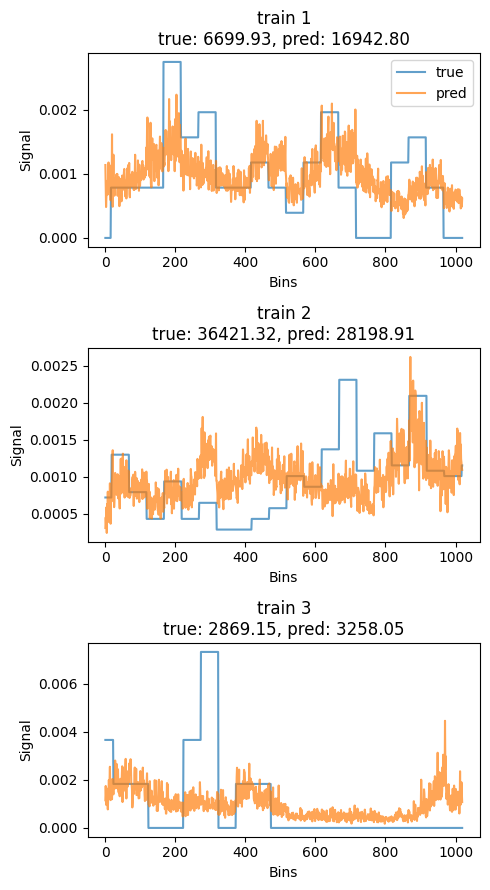

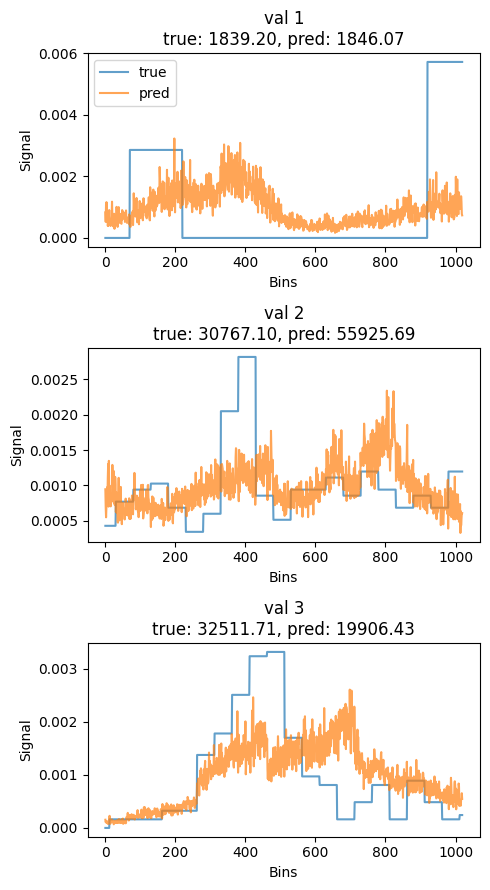

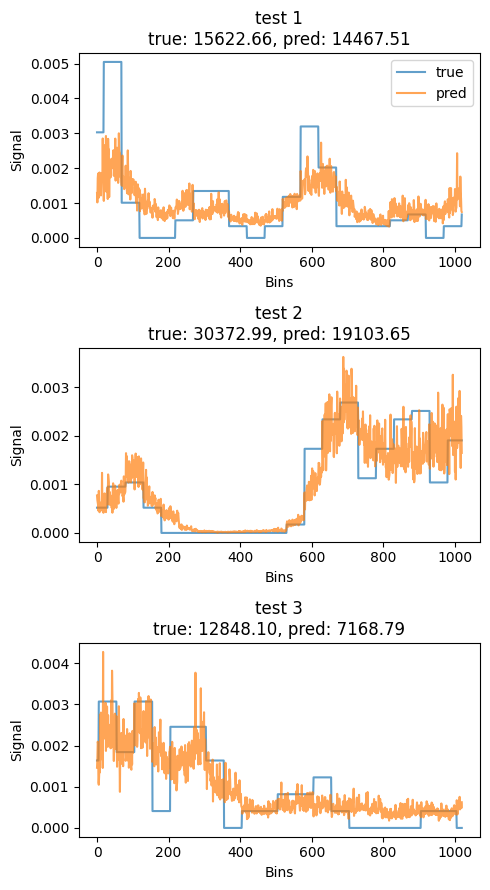

In [17]:
visualize_split_predictions(
    model,
    device='cpu',
    n_examples_per_split=3,
    smooth_pred=False,
    smooth_true=False,
)

### Track motifs

In [20]:
import os
import torch

os.environ['NUMBA_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['KMP_WARNINGS'] = '0'

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="captum")

    

In [21]:
loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)
len(loader.dataset)

3640

In [23]:
min_profile = window_left + window_right
min_profile

1020

In [25]:
import warnings
import os

warnings.filterwarnings("ignore", category=UserWarning, module="captum")
os.environ['KMP_WARNINGS'] = '0'


In [ ]:
from motif import discover_motifs

pos, neg = discover_motifs(
    model, loader=model.test_loader, device='mps', min_counts=min_profile, 
    save_path=f'../{results_dir}/modisco_profile.h5'
)

In [ ]:
print(f'modisco report -i {results_dir}/modisco_profile.h5 -o {results_dir}/report/  -m ../data/JASPAR2024_CORE_vertebrates.meme')

modisco report -i ../results/seqpol2_2H_20260505/modisco_profile.h5 -o ../results/seqpol2_2H_20260505/report/  -m ../data/JASPAR2024_CORE_vertebrates.meme
